### Secant Method

The **Secant Method** is a root-finding algorithm similar to Newton–Raphson, but it avoids the need for an explicit derivative by approximating it using two previous iterates.
$$
x_{n+1} = x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}
$$

Two initial guesses \\(x_0\\) and \\(x_1\\) are required. The method repeatedly draws a secant line through the last two points and uses its root as the next estimate.

The secant method generally converges **superlinearly** (slower than Newton–Raphson but faster than bisection), and unlike Newton–Raphson it does **not require derivative evaluation**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x**3 - x - 2


In [3]:
def secant_table(f, x0, x1, tol=1e-6, max_iter=100):
    print(f"{'n':>2} {'x0':>10} {'x1':>10} {'x2':>10} {'f(x2)':>12} {'error':>12}")
    print("-" * 60)

    for n in range(1, max_iter + 1):
        if f(x1) - f(x0) == 0:
            raise ZeroDivisionError("Division by zero in secant formula")

        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        error = abs(x2 - x1)

        print(f"{n:2d} {x0:10.6f} {x1:10.6f} {x2:10.6f} {f(x2):12.6e} {error:12.6e}")

        if error < tol or abs(f(x2)) < tol:
            print(f"\nConverged in {n} iterations")
            return x2

        x0, x1 = x1, x2

    raise RuntimeError("Maximum iterations reached")


In [4]:
root = secant_table(f, x0=1, x1=2)
print("Root =", root)


 n         x0         x1         x2        f(x2)        error
------------------------------------------------------------
 1   1.000000   2.000000   1.333333 -9.629630e-01 6.666667e-01
 2   2.000000   1.333333   1.462687 -3.333389e-01 1.293532e-01
 3   1.333333   1.462687   1.531169 5.862642e-02 6.848286e-02
 4   1.462687   1.531169   1.520926 -2.693300e-03 1.024301e-02
 5   1.531169   1.520926   1.521376 -2.015019e-05 4.498962e-04
 6   1.520926   1.521376   1.521380 7.015478e-09 3.391315e-06

Converged in 6 iterations
Root = 1.5213797079848717


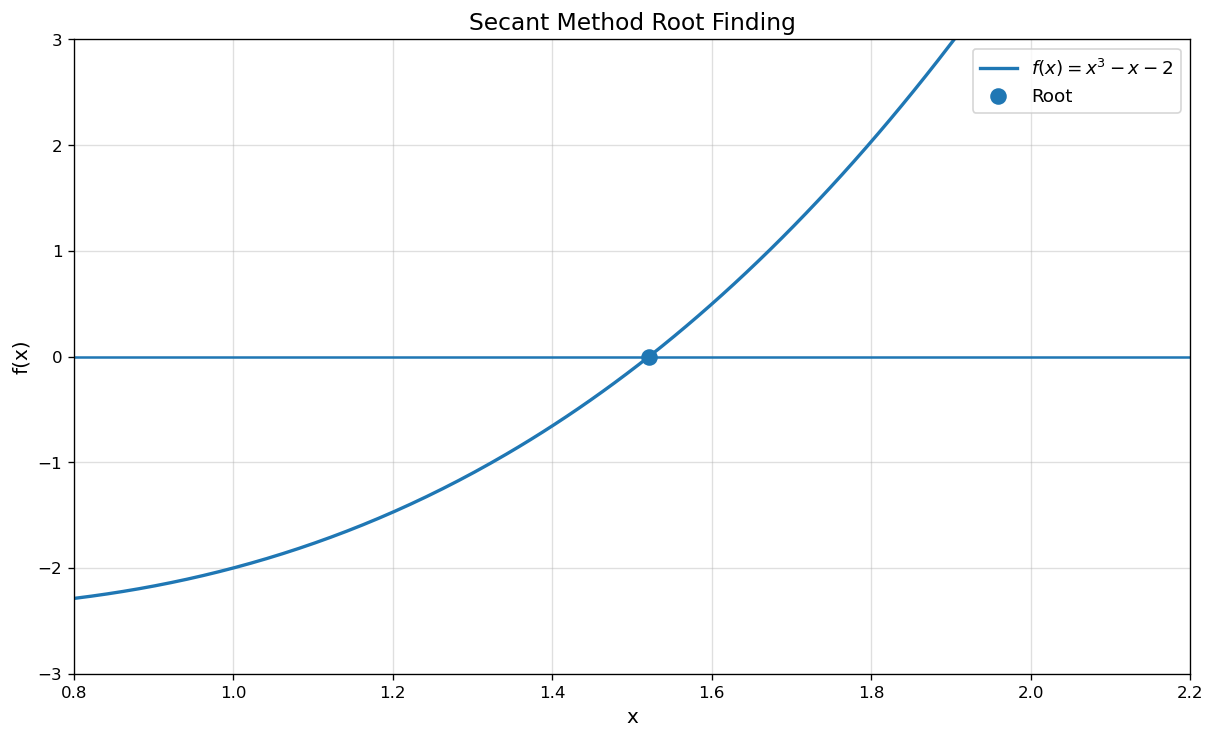

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x = np.linspace(0, 2.5, 500)
y = f(x)

plt.plot(x, y, linewidth=2, label=r"$f(x)=x^3-x-2$")
plt.scatter(root, f(root), s=80, zorder=5, label="Root")

plt.xlim(0.8, 2.2)
plt.ylim(-3, 3)
plt.grid(True, alpha=0.4)

plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.title("Secant Method Root Finding", fontsize=14)

plt.legend(fontsize=11)
plt.show()
